In [2]:
# ============================================================
# HR Analytics EDA — IBM Employee Attrition Dataset
# Author: Piyush | Tools: Python, Pandas, Seaborn, Matplotlib
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Plot styling
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [3]:
# Load the dataset
df = pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')

# First look
print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape: (1470, 35)

First 5 rows:


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [4]:
# Column data types and non-null counts
print("Dataset Info:")
print(df.info())

# Missing values check
print("\nMissing Values:")
print(df.isnull().sum())

# Basic statistics
print("\nBasic Statistics:")
df.describe()

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   str  
 2   BusinessTravel            1470 non-null   str  
 3   DailyRate                 1470 non-null   int64
 4   Department                1470 non-null   str  
 5   DistanceFromHome          1470 non-null   int64
 6   Education                 1470 non-null   int64
 7   EducationField            1470 non-null   str  
 8   EmployeeCount             1470 non-null   int64
 9   EmployeeNumber            1470 non-null   int64
 10  EnvironmentSatisfaction   1470 non-null   int64
 11  Gender                    1470 non-null   str  
 12  HourlyRate                1470 non-null   int64
 13  JobInvolvement            1470 non-null   int64
 14  JobLevel                  1470 non-nu

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [5]:
# ── Feature Engineering ──────────────────────────────────────

# 1. Attrition as a number (Yes=1, No=0) — useful for calculations
df['Attrition_Flag'] = df['Attrition'].apply(lambda x: 1 if x == 'Yes' else 0)

# 2. Age groups
df['Age_Group'] = pd.cut(df['Age'], 
                          bins=[18, 25, 35, 45, 60], 
                          labels=['18-25', '26-35', '36-45', '46-60'])

# 3. Salary bands
df['Salary_Band'] = pd.cut(df['MonthlyIncome'], 
                            bins=[0, 3000, 6000, 10000, 20000], 
                            labels=['Low', 'Medium', 'High', 'Very High'])

# 4. Tenure groups
df['Tenure_Group'] = pd.cut(df['YearsAtCompany'], 
                             bins=[-1, 2, 5, 10, 40], 
                             labels=['0-2 yrs', '3-5 yrs', '6-10 yrs', '10+ yrs'])

# Verify new columns
print("✅ New columns added:")
print(df[['Age', 'Age_Group', 'MonthlyIncome', 'Salary_Band', 
          'YearsAtCompany', 'Tenure_Group', 'Attrition', 'Attrition_Flag']].head(10))
          

✅ New columns added:
   Age Age_Group  MonthlyIncome Salary_Band  YearsAtCompany Tenure_Group  \
0   41     36-45           5993      Medium               6     6-10 yrs   
1   49     46-60           5130      Medium              10     6-10 yrs   
2   37     36-45           2090         Low               0      0-2 yrs   
3   33     26-35           2909         Low               8     6-10 yrs   
4   27     26-35           3468      Medium               2      0-2 yrs   
5   32     26-35           3068      Medium               7     6-10 yrs   
6   59     46-60           2670         Low               1      0-2 yrs   
7   30     26-35           2693         Low               1      0-2 yrs   
8   38     36-45           9526        High               9     6-10 yrs   
9   36     36-45           5237      Medium               7     6-10 yrs   

  Attrition  Attrition_Flag  
0       Yes               1  
1        No               0  
2       Yes               1  
3        No           

In [6]:
# ── Key Business Metrics ─────────────────────────────────────
total_emp = len(df)
attrition_rate = df['Attrition_Flag'].mean() * 100
avg_age = df['Age'].mean()
avg_salary = df['MonthlyIncome'].mean()
avg_tenure = df['YearsAtCompany'].mean()

print("=" * 45)
print("        HR ANALYTICS — KEY METRICS")
print("=" * 45)
print(f"  Total Employees        : {total_emp}")
print(f"  Attrition Rate         : {attrition_rate:.1f}%")
print(f"  Average Age            : {avg_age:.1f} years")
print(f"  Average Monthly Salary : ₹{avg_salary:,.0f}")
print(f"  Average Tenure         : {avg_tenure:.1f} years")
print("=" * 45)

        HR ANALYTICS — KEY METRICS
  Total Employees        : 1470
  Attrition Rate         : 16.1%
  Average Age            : 36.9 years
  Average Monthly Salary : ₹6,503
  Average Tenure         : 7.0 years


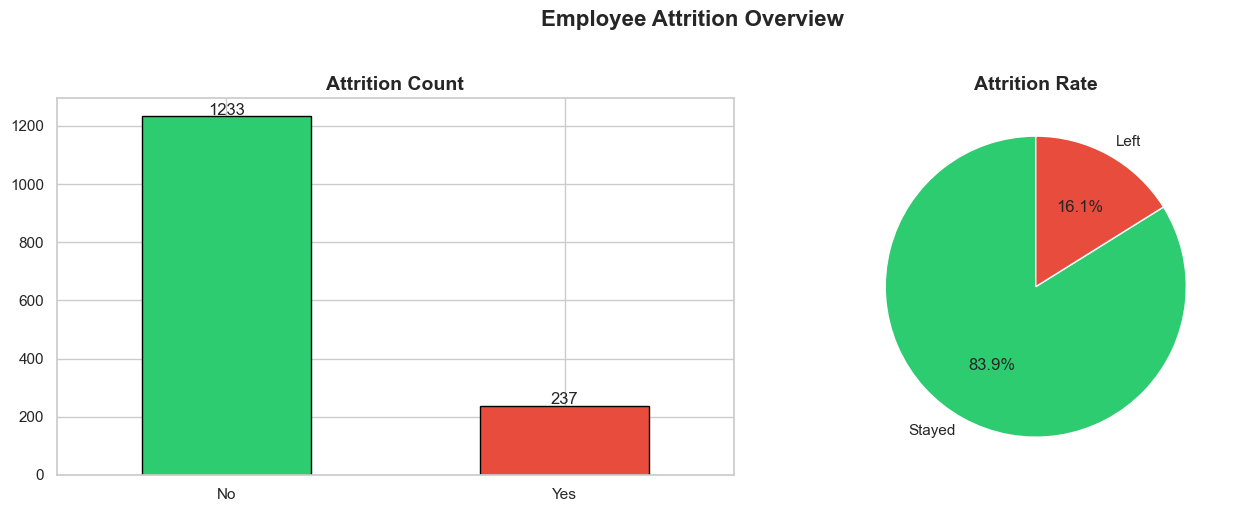

✅ Chart 1 saved!


In [7]:
# ── Chart 1: Attrition Count & Rate ──────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count
df['Attrition'].value_counts().plot(kind='bar', ax=axes[0],
    color=['#2ecc71', '#e74c3c'], edgecolor='black', width=0.5)
axes[0].set_title('Attrition Count', fontsize=14, fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_xticklabels(['No', 'Yes'], rotation=0)
for p in axes[0].patches:
    axes[0].annotate(str(int(p.get_height())),
        (p.get_x() + p.get_width()/2, p.get_height() + 5),
        ha='center', fontsize=12)

# Pie
df['Attrition'].value_counts().plot(kind='pie', ax=axes[1],
    colors=['#2ecc71', '#e74c3c'], autopct='%1.1f%%',
    startangle=90, labels=['Stayed', 'Left'])
axes[1].set_title('Attrition Rate', fontsize=14, fontweight='bold')
axes[1].set_ylabel('')

plt.suptitle('Employee Attrition Overview', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('chart1_attrition_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 1 saved!")

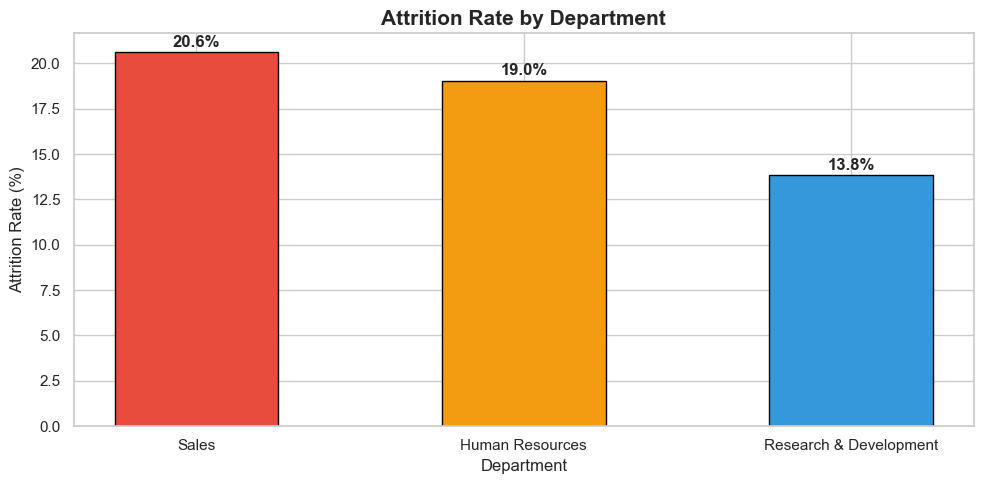

✅ Chart 2 saved!


In [8]:
# ── Chart 2: Attrition Rate by Department ────────────────────
dept_attr = df.groupby('Department')['Attrition_Flag'].mean() * 100
dept_attr = dept_attr.sort_values(ascending=False)

plt.figure(figsize=(10, 5))
bars = plt.bar(dept_attr.index, dept_attr.values,
               color=['#e74c3c', '#f39c12', '#3498db'], edgecolor='black', width=0.5)
plt.title('Attrition Rate by Department', fontsize=15, fontweight='bold')
plt.xlabel('Department')
plt.ylabel('Attrition Rate (%)')
for bar, val in zip(bars, dept_attr.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{val:.1f}%', ha='center', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('chart2_attrition_by_dept.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 2 saved!")

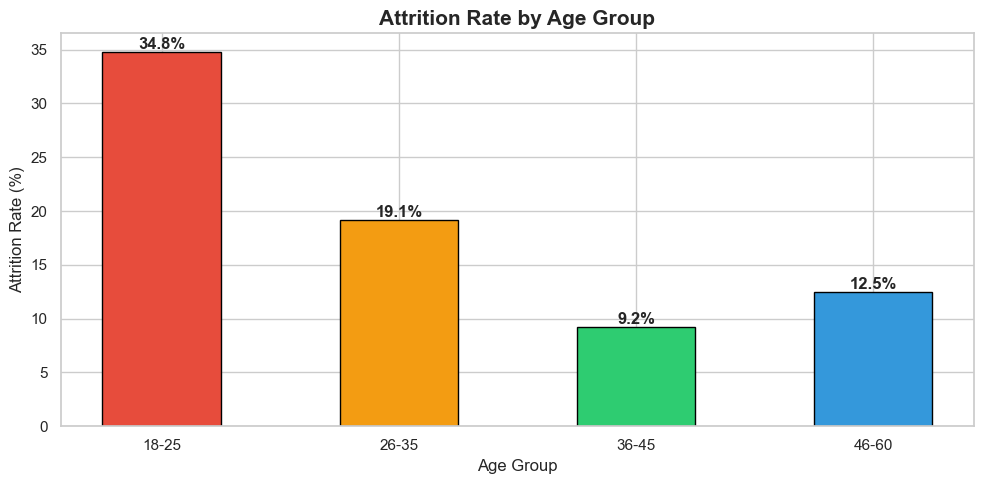

✅ Chart 3 saved!


In [9]:
# ── Chart 3: Attrition Rate by Age Group ─────────────────────
age_attr = df.groupby('Age_Group', observed=True)['Attrition_Flag'].mean() * 100

plt.figure(figsize=(10, 5))
bars = plt.bar(age_attr.index.astype(str), age_attr.values,
               color=['#e74c3c', '#f39c12', '#2ecc71', '#3498db'],
               edgecolor='black', width=0.5)
plt.title('Attrition Rate by Age Group', fontsize=15, fontweight='bold')
plt.xlabel('Age Group')
plt.ylabel('Attrition Rate (%)')
for bar, val in zip(bars, age_attr.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{val:.1f}%', ha='center', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('chart3_attrition_by_age.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 3 saved!")

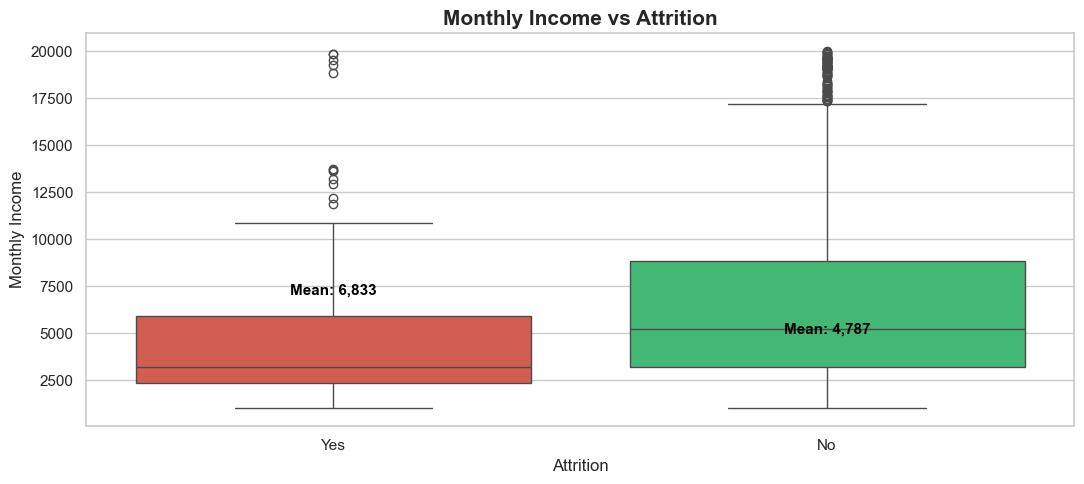

✅ Chart 4 saved!


In [10]:
# ── Chart 4: Monthly Income Distribution by Attrition ────────
plt.figure(figsize=(11, 5))
sns.boxplot(data=df, x='Attrition', y='MonthlyIncome',
            palette={'Yes': '#e74c3c', 'No': '#2ecc71'})
plt.title('Monthly Income vs Attrition', fontsize=15, fontweight='bold')
plt.xlabel('Attrition')
plt.ylabel('Monthly Income')

# Add mean labels
for i, group in enumerate(['No', 'Yes']):
    mean_val = df[df['Attrition'] == group]['MonthlyIncome'].mean()
    plt.text(i, mean_val + 200, f'Mean: {mean_val:,.0f}',
             ha='center', fontsize=11, color='black', fontweight='bold')

plt.tight_layout()
plt.savefig('chart4_salary_vs_attrition.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 4 saved!")

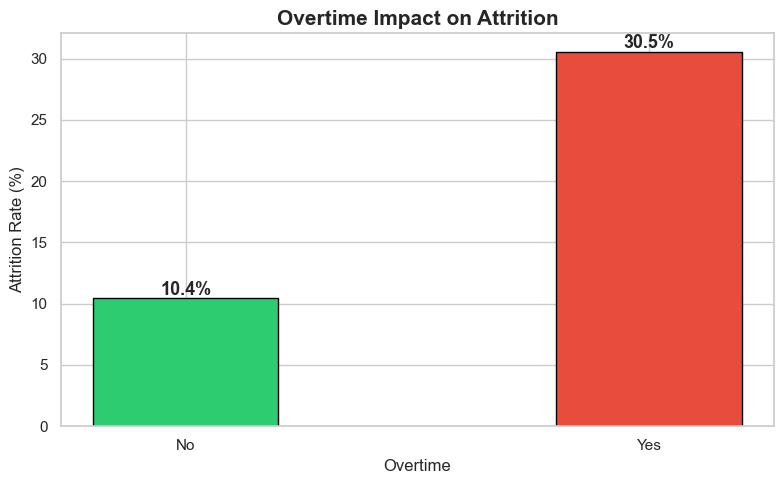

✅ Chart 5 saved!


In [11]:
# ── Chart 5: Overtime Impact on Attrition ────────────────────
ot_attr = df.groupby('OverTime')['Attrition_Flag'].mean() * 100

plt.figure(figsize=(8, 5))
bars = plt.bar(ot_attr.index, ot_attr.values,
               color=['#2ecc71', '#e74c3c'], edgecolor='black', width=0.4)
plt.title('Overtime Impact on Attrition', fontsize=15, fontweight='bold')
plt.xlabel('Overtime')
plt.ylabel('Attrition Rate (%)')
for bar, val in zip(bars, ot_attr.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{val:.1f}%', ha='center', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('chart5_overtime_attrition.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 5 saved!")

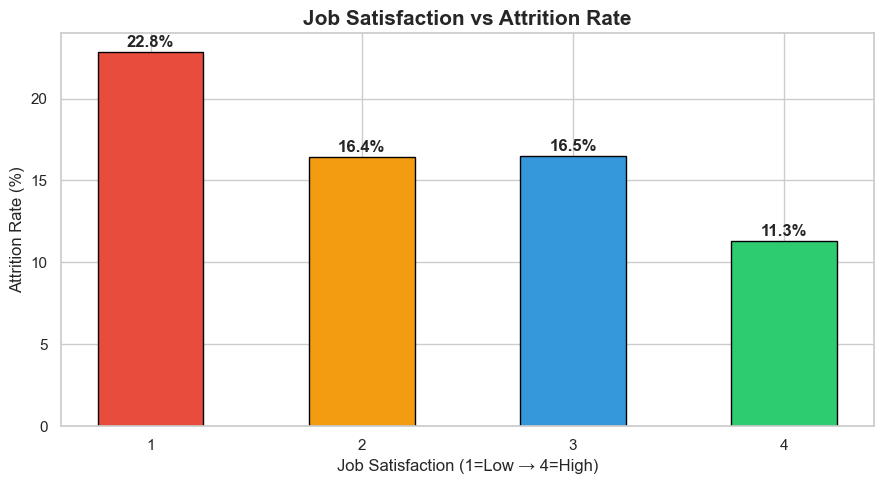

✅ Chart 6 saved!


In [12]:
# ── Chart 6: Job Satisfaction vs Attrition ───────────────────
js_attr = df.groupby('JobSatisfaction')['Attrition_Flag'].mean() * 100

plt.figure(figsize=(9, 5))
bars = plt.bar(js_attr.index.astype(str), js_attr.values,
               color=['#e74c3c', '#f39c12', '#3498db', '#2ecc71'],
               edgecolor='black', width=0.5)
plt.title('Job Satisfaction vs Attrition Rate', fontsize=15, fontweight='bold')
plt.xlabel('Job Satisfaction (1=Low → 4=High)')
plt.ylabel('Attrition Rate (%)')
for bar, val in zip(bars, js_attr.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{val:.1f}%', ha='center', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('chart6_jobsatisfaction_attrition.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 6 saved!")

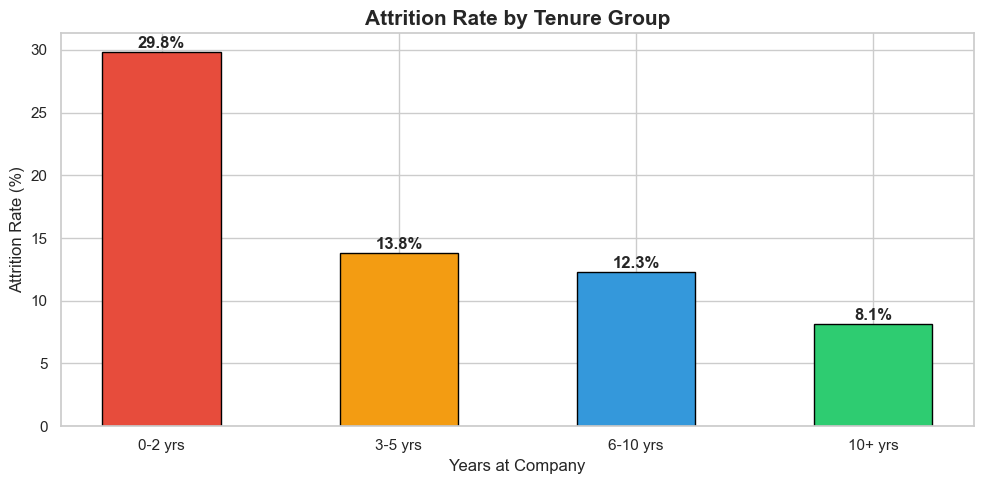

✅ Chart 7 saved!


In [13]:
# ── Chart 7: Attrition by Tenure ─────────────────────────────
tenure_attr = df.groupby('Tenure_Group', observed=True)['Attrition_Flag'].mean() * 100

plt.figure(figsize=(10, 5))
bars = plt.bar(tenure_attr.index.astype(str), tenure_attr.values,
               color=['#e74c3c', '#f39c12', '#3498db', '#2ecc71'],
               edgecolor='black', width=0.5)
plt.title('Attrition Rate by Tenure Group', fontsize=15, fontweight='bold')
plt.xlabel('Years at Company')
plt.ylabel('Attrition Rate (%)')
for bar, val in zip(bars, tenure_attr.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{val:.1f}%', ha='center', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('chart7_attrition_by_tenure.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 7 saved!")


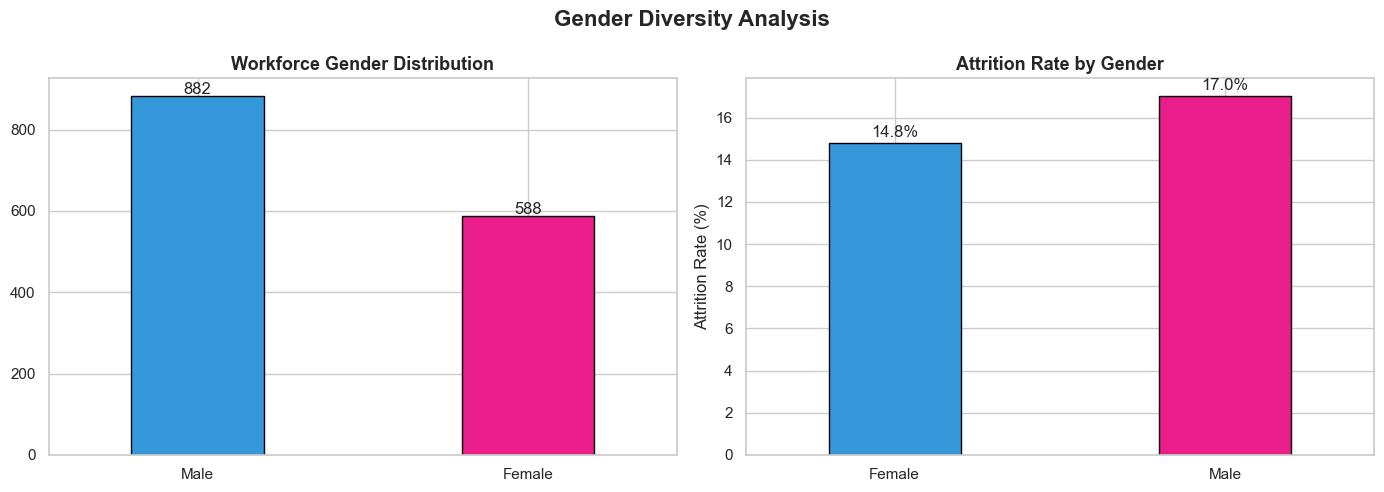

✅ Chart 8 saved!


In [14]:
# ── Chart 8: Gender Diversity & Attrition ────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gender distribution
df['Gender'].value_counts().plot(kind='bar', ax=axes[0],
    color=['#3498db', '#e91e8c'], edgecolor='black', width=0.4)
axes[0].set_title('Workforce Gender Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_xticklabels(df['Gender'].value_counts().index, rotation=0)
for p in axes[0].patches:
    axes[0].annotate(str(int(p.get_height())),
        (p.get_x() + p.get_width()/2, p.get_height() + 5),
        ha='center', fontsize=12)

# Attrition rate by gender
gender_attr = df.groupby('Gender')['Attrition_Flag'].mean() * 100
gender_attr.plot(kind='bar', ax=axes[1],
    color=['#3498db', '#e91e8c'], edgecolor='black', width=0.4)
axes[1].set_title('Attrition Rate by Gender', fontsize=13, fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_xticklabels(gender_attr.index, rotation=0)
axes[1].set_ylabel('Attrition Rate (%)')
for p in axes[1].patches:
    axes[1].annotate(f'{p.get_height():.1f}%',
        (p.get_x() + p.get_width()/2, p.get_height() + 0.3),
        ha='center', fontsize=12)

plt.suptitle('Gender Diversity Analysis', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('chart8_gender_diversity.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 8 saved!")

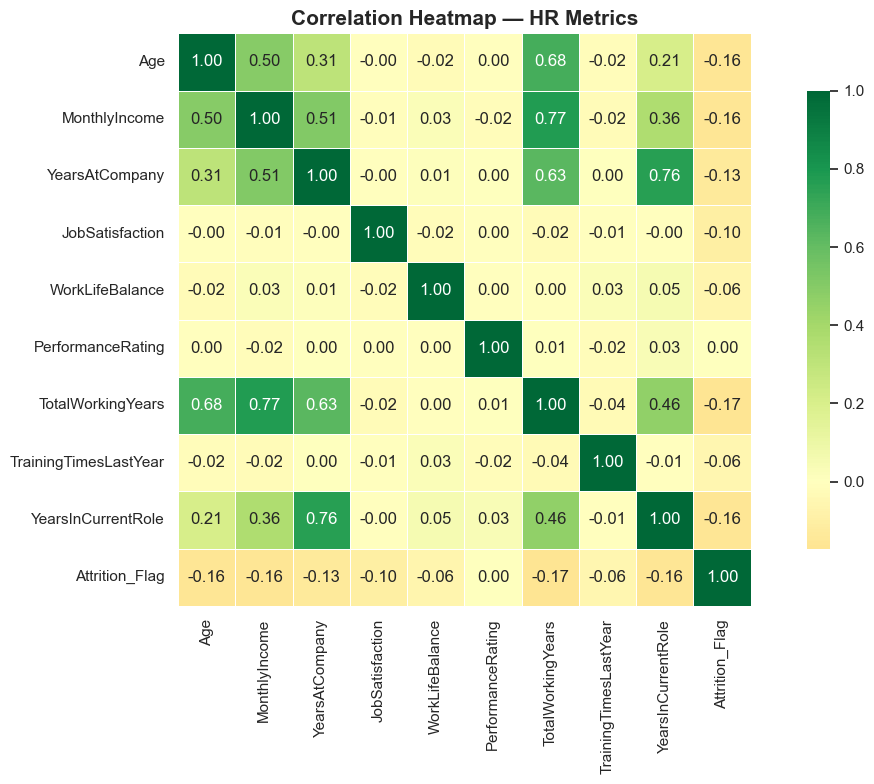

✅ Chart 9 saved!


In [15]:
# ── Chart 9: Correlation Heatmap ─────────────────────────────
numeric_cols = ['Age', 'MonthlyIncome', 'YearsAtCompany', 'JobSatisfaction',
                'WorkLifeBalance', 'PerformanceRating', 'TotalWorkingYears',
                'TrainingTimesLastYear', 'YearsInCurrentRole', 'Attrition_Flag']

corr = df[numeric_cols].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=0.5, square=True,
            cbar_kws={'shrink': 0.8})
plt.title('Correlation Heatmap — HR Metrics', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('chart9_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 9 saved!")

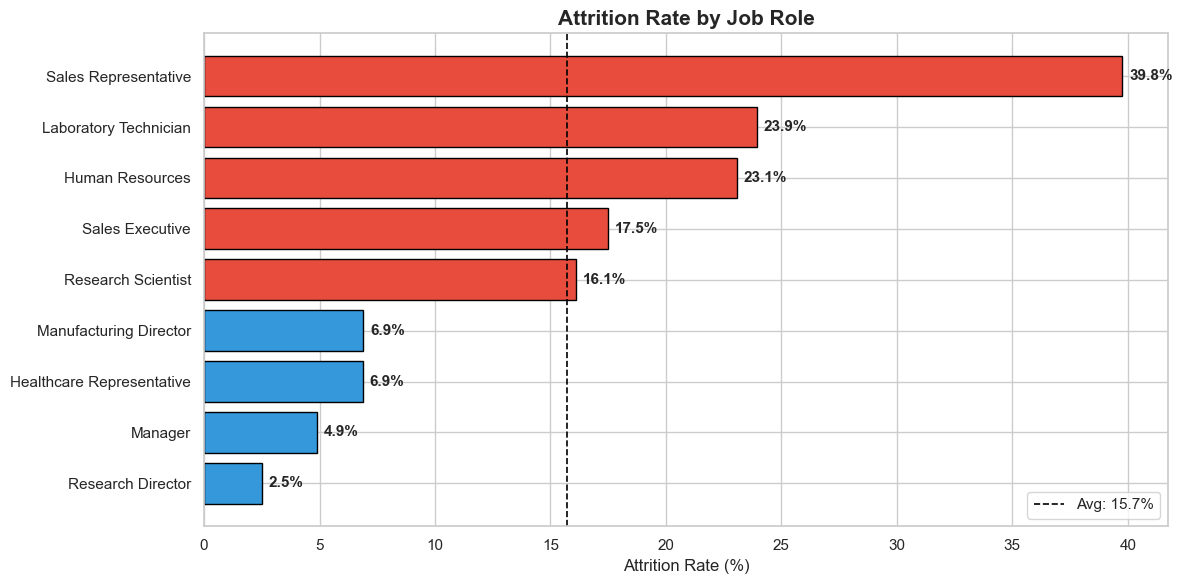

✅ Chart 10 saved!


In [16]:
# ── Chart 10: Attrition Rate by Job Role ─────────────────────
role_attr = df.groupby('JobRole')['Attrition_Flag'].mean() * 100
role_attr = role_attr.sort_values(ascending=True)

plt.figure(figsize=(12, 6))
bars = plt.barh(role_attr.index, role_attr.values,
                color=['#e74c3c' if v > 15 else '#3498db' for v in role_attr.values],
                edgecolor='black')
plt.title('Attrition Rate by Job Role', fontsize=15, fontweight='bold')
plt.xlabel('Attrition Rate (%)')
plt.ylabel('')
for bar, val in zip(bars, role_attr.values):
    plt.text(val + 0.3, bar.get_y() + bar.get_height()/2,
             f'{val:.1f}%', va='center', fontsize=11, fontweight='bold')
plt.axvline(x=role_attr.mean(), color='black', linestyle='--', linewidth=1.2, label=f'Avg: {role_attr.mean():.1f}%')
plt.legend()
plt.tight_layout()
plt.savefig('chart10_attrition_by_role.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 10 saved!")

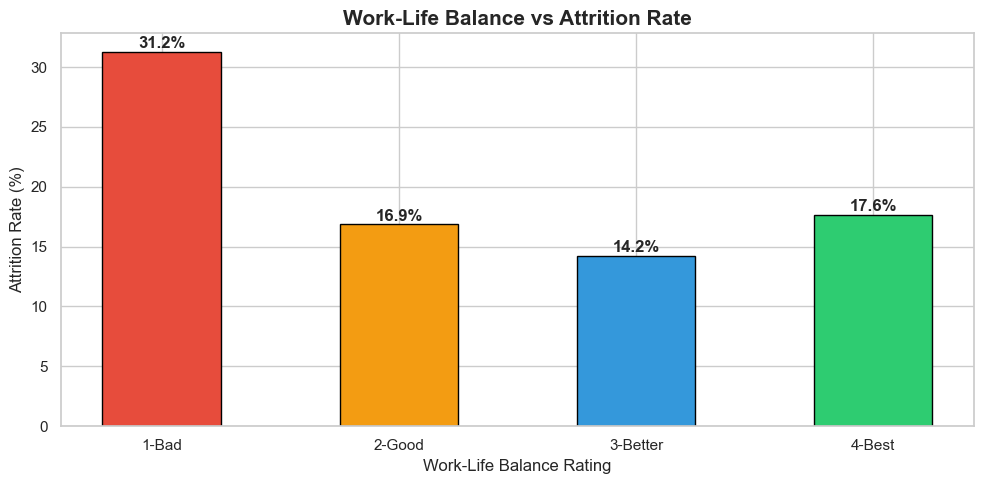

✅ Chart 11 saved!


In [17]:
# ── Chart 11: Work Life Balance vs Attrition ─────────────────
wlb_attr = df.groupby('WorkLifeBalance')['Attrition_Flag'].mean() * 100
labels = {1: '1-Bad', 2: '2-Good', 3: '3-Better', 4: '4-Best'}
wlb_attr.index = wlb_attr.index.map(labels)

plt.figure(figsize=(10, 5))
bars = plt.bar(wlb_attr.index, wlb_attr.values,
               color=['#e74c3c', '#f39c12', '#3498db', '#2ecc71'],
               edgecolor='black', width=0.5)
plt.title('Work-Life Balance vs Attrition Rate', fontsize=15, fontweight='bold')
plt.xlabel('Work-Life Balance Rating')
plt.ylabel('Attrition Rate (%)')
for bar, val in zip(bars, wlb_attr.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{val:.1f}%', ha='center', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('chart11_worklife_attrition.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 11 saved!")

In [18]:
# ── Key Insights Summary ──────────────────────────────────────
print("=" * 55)
print("        HR ANALYTICS — KEY INSIGHTS SUMMARY")
print("=" * 55)

print(f"""
📊 WORKFORCE OVERVIEW
   • Total Employees     : {len(df)}
   • Attrition Rate      : {df['Attrition_Flag'].mean()*100:.1f}%
   • Employees Left      : {df['Attrition_Flag'].sum()}
   • Average Age         : {df['Age'].mean():.1f} years
   • Average Salary      : ${df['MonthlyIncome'].mean():,.0f}/month
   • Average Tenure      : {df['YearsAtCompany'].mean():.1f} years

🚨 ATTRITION RISK FACTORS
   • Overtime workers leave at {df[df['OverTime']=='Yes']['Attrition_Flag'].mean()*100:.1f}% vs {df[df['OverTime']=='No']['Attrition_Flag'].mean()*100:.1f}% (no overtime)
   • Lowest salary band attrition: {df[df['Salary_Band']=='Low']['Attrition_Flag'].mean()*100:.1f}%
   • Highest risk age group: 18-25 at {df[df['Age_Group']=='18-25']['Attrition_Flag'].mean()*100:.1f}%
   • Employees with 0-2 yrs tenure: {df[df['Tenure_Group']=='0-2 yrs']['Attrition_Flag'].mean()*100:.1f}% attrition rate

🏢 DEPARTMENT INSIGHTS
""")

for dept in df['Department'].unique():
    rate = df[df['Department']==dept]['Attrition_Flag'].mean()*100
    print(f"   • {dept:<35}: {rate:.1f}%")

print(f"""
👥 DIVERSITY
   • Male employees      : {len(df[df['Gender']=='Male'])} ({len(df[df['Gender']=='Male'])/len(df)*100:.1f}%)
   • Female employees    : {len(df[df['Gender']=='Female'])} ({len(df[df['Gender']=='Female'])/len(df)*100:.1f}%)
   • Male attrition      : {df[df['Gender']=='Male']['Attrition_Flag'].mean()*100:.1f}%
   • Female attrition    : {df[df['Gender']=='Female']['Attrition_Flag'].mean()*100:.1f}%
""")
print("=" * 55)
print("✅ Analysis Complete!")

        HR ANALYTICS — KEY INSIGHTS SUMMARY

📊 WORKFORCE OVERVIEW
   • Total Employees     : 1470
   • Attrition Rate      : 16.1%
   • Employees Left      : 237
   • Average Age         : 36.9 years
   • Average Salary      : $6,503/month
   • Average Tenure      : 7.0 years

🚨 ATTRITION RISK FACTORS
   • Overtime workers leave at 30.5% vs 10.4% (no overtime)
   • Lowest salary band attrition: 28.6%
   • Highest risk age group: 18-25 at 34.8%
   • Employees with 0-2 yrs tenure: 29.8% attrition rate

🏢 DEPARTMENT INSIGHTS

   • Sales                              : 20.6%
   • Research & Development             : 13.8%
   • Human Resources                    : 19.0%

👥 DIVERSITY
   • Male employees      : 882 (60.0%)
   • Female employees    : 588 (40.0%)
   • Male attrition      : 17.0%
   • Female attrition    : 14.8%

✅ Analysis Complete!


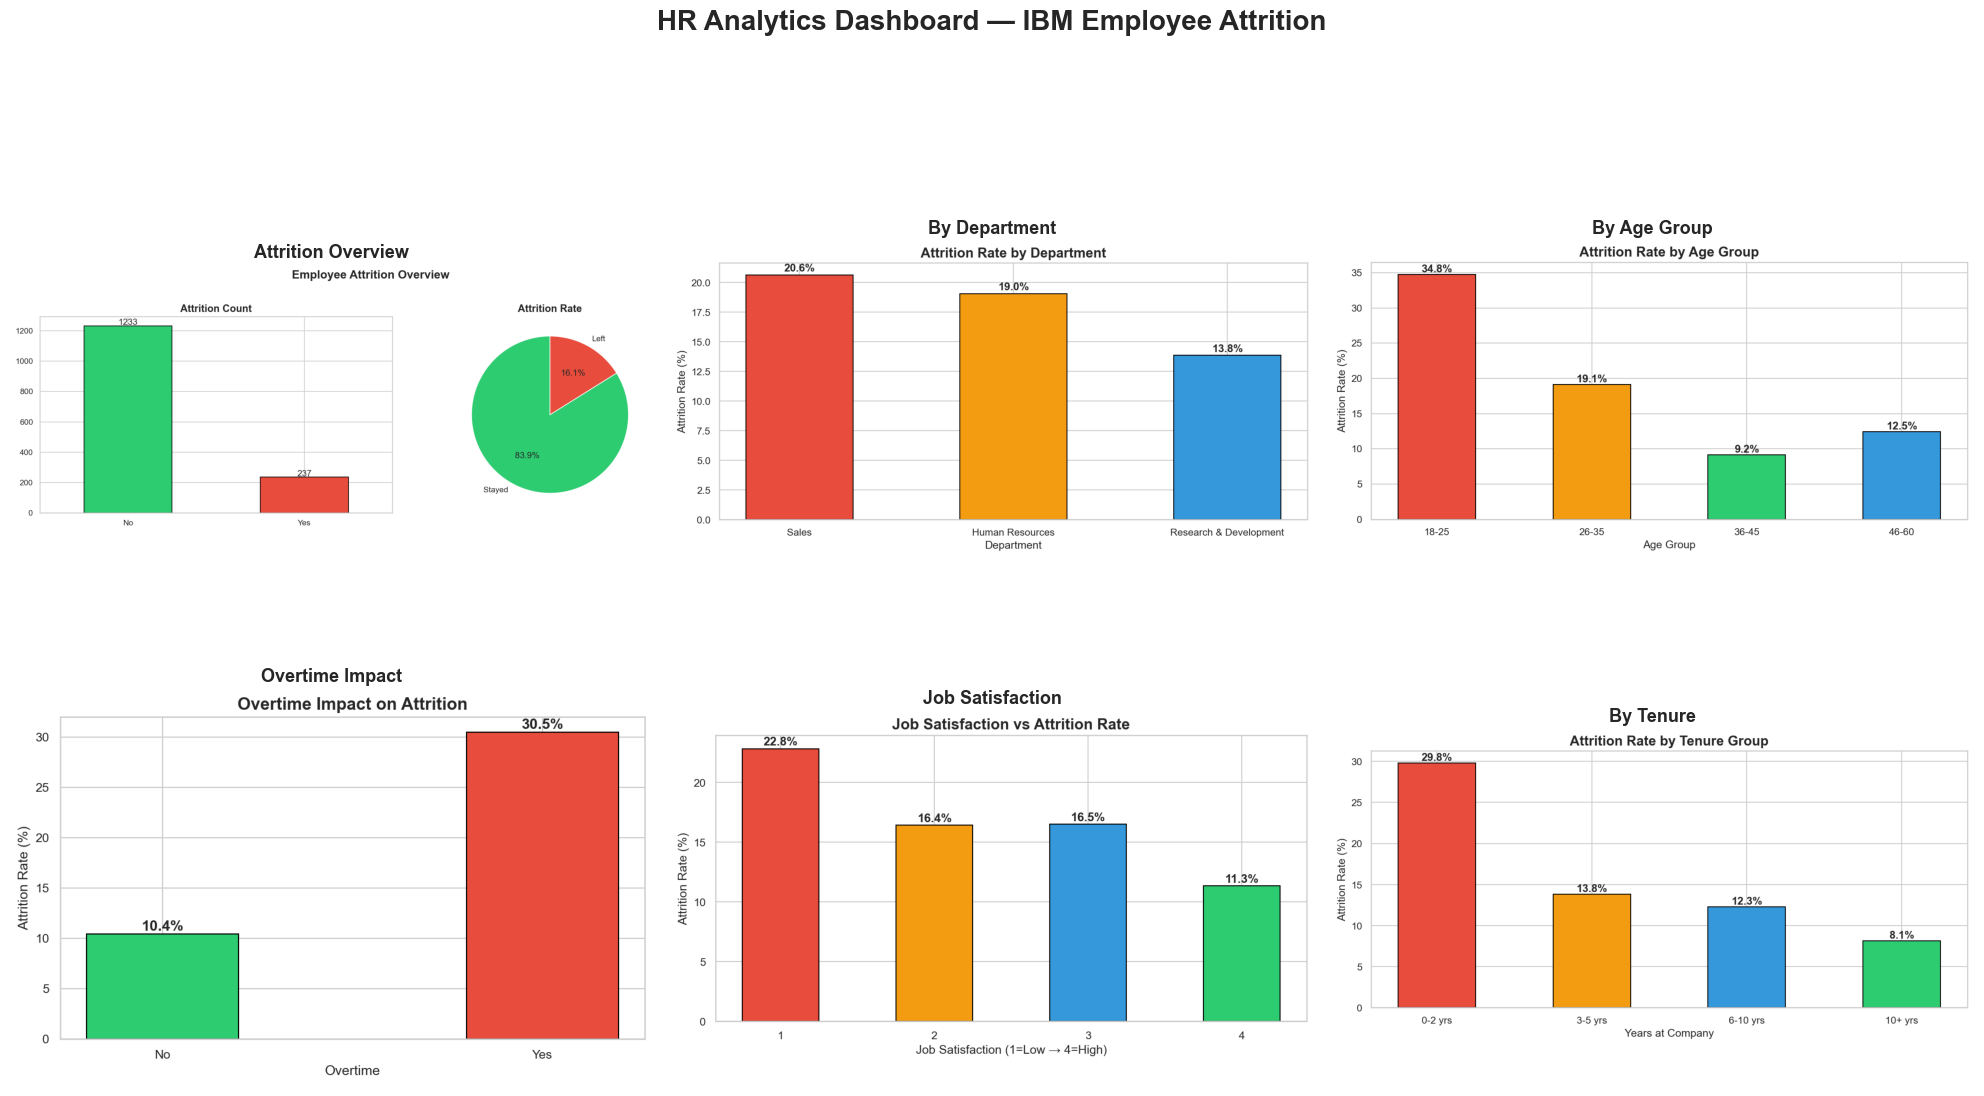

✅ Dashboard summary saved!


In [19]:
# ── Combined Dashboard Summary Figure ────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('HR Analytics Dashboard — IBM Employee Attrition',
             fontsize=20, fontweight='bold', y=1.01)

charts = [
    ('chart1_attrition_overview.png', 'Attrition Overview'),
    ('chart2_attrition_by_dept.png', 'By Department'),
    ('chart3_attrition_by_age.png', 'By Age Group'),
    ('chart5_overtime_attrition.png', 'Overtime Impact'),
    ('chart6_jobsatisfaction_attrition.png', 'Job Satisfaction'),
    ('chart7_attrition_by_tenure.png', 'By Tenure'),
]

from matplotlib.image import imread
for ax, (path, title) in zip(axes.flatten(), charts):
    try:
        img = imread(path)
        ax.imshow(img)
        ax.set_title(title, fontsize=13, fontweight='bold')
        ax.axis('off')
    except:
        ax.set_visible(False)

plt.tight_layout()
plt.savefig('HR_Analytics_Dashboard_Summary.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Dashboard summary saved!")